In [ ]:
from inputs.source import Source
from inputs.spectrum import Spectrum
from inputs.experiment import Experiment
from propagation import YEAR_TO_SEC, DAY_TO_SEC
from outputs.output_handler import OutputHandler
from plots import Plot
import os

Etot = 1e-2
time_delays = {
    'day': DAY_TO_SEC,
    'yr': YEAR_TO_SEC,
    '1e6': 1e6
}
experiment = Experiment(integration_time=DAY_TO_SEC, integration_time_DM=YEAR_TO_SEC, sensitivity=1e-18, time_delays = time_delays)

masses_kpc = [1e-20, 1e-15]
times = [1, 100]
    
sources_grid = [
    [Source(1e-2, mass=m, tstar=t, R=1e4, ULB_type='ALP', coupling_type='electron') for m in masses_kpc] for t in times
]

spectra_grid = [
    [Spectrum(source=s, experiment=experiment) for s in row] for row in sources_grid
]

In [ ]:
legend_config = {
    'frameon': False,
    'bbox_to_anchor': (0.88, 0.88)
}
plot = Plot(xlims=(1e-21, 6e-6), ylims=(5e-12, 2e-8), exclude_mass=False, include_legend=True, legend_config=legend_config)
output = OutputHandler(plot)
output.plot_parameter_space(sources_grid, spectra_grid, plot, save_path='test2x2.png')

In [ ]:
from inputs.source import Source
from inputs.spectrum import Spectrum
from inputs.experiment import Experiment
from propagation import YEAR_TO_SEC, DAY_TO_SEC
from outputs.output_handler import OutputHandler
from plots import Plot

Etot = 1e-2
time_delays = {
    'day': DAY_TO_SEC,
    'yr': YEAR_TO_SEC,
    '1e6': 1e6
}
experiment = Experiment(integration_time=DAY_TO_SEC, integration_time_DM=YEAR_TO_SEC, sensitivity=1e-18, time_delays = time_delays)

masses_kpc = [1e-20, 1e-15]
times = [1, 100]
sources_grid = [
    [Source(1e-2, mass=m, tstar=t, R=1e4, ULB_type='scalar', coupling_type='electron', coupling_order='linear') for m in masses_kpc] for t in times
]

spectra_grid = [
    [Spectrum(source=s, experiment=experiment) for s in row] for row in sources_grid
]

In [ ]:
legend_config = {
    'frameon': False,
    'bbox_to_anchor': (0.88, 0.88)
}
plot = Plot(xlims=(1e-21, 6e-6), ylims=(5e-12, 2e-8), exclude_mass=False, include_legend=True, legend_config=legend_config)
output = OutputHandler(plot)
output.plot_parameter_space(sources_grid, spectra_grid, plot, save_path='test2x2.png')

In [ ]:
from inputs.source import Source
from inputs.spectrum import Spectrum
from inputs.experiment import Experiment
from propagation import YEAR_TO_SEC, DAY_TO_SEC
from outputs.output_handler import OutputHandler
from plots import Plot
from constants import KPC_TO_INEV, SEC_TO_INEV

import os

experiment = Experiment(DAY_TO_SEC, YEAR_TO_SEC, 1e-17, {'day': DAY_TO_SEC, 'yr': YEAR_TO_SEC})

filename = 'bosenova.param'
if os.path.exists(filename):
    with open(filename, 'r') as f:
        params = {}
        for line in f:
            key, value = line.strip().split("=")
            params[key] = float(value)

        density = params['AVG_DENSITY']
        tstar = params['BURST_DURATION']
        R = params['DISTANCE'] / KPC_TO_INEV * 1000
        m = params['MASS']
        
else:
    m = 1e-20
    R = 1e4
    tstar = 1
    density = None

source = Source(1e-2, mass=m, tstar=tstar, R=R, ULB_type='ALP', coupling_type='electron', coupling_order='quad')
spectrum = Spectrum(source=source, experiment=experiment, rho=density)

print(f'mass={source.mass} R={source.R} tstar={source.tstar} density={spectrum.rho}')


mass=1e-19 R=1.09611814 tstar=2632800.0 density=[1.41279822e-103 5.66740332e-006 6.61125316e-006 6.98820039e-006
 7.18506794e-006 7.30259479e-006 7.37857877e-006 7.43035107e-006
 7.46694934e-006 7.49352896e-006 7.51323149e-006 7.52807026e-006
 7.53938755e-006 7.54810696e-006 7.55488055e-006 7.56017844e-006
 7.56434559e-006 7.56763886e-006 7.57025186e-006 7.57233210e-006
 7.57399294e-006 7.57532216e-006 7.57638820e-006 7.57724468e-006
 7.57793387e-006 7.57848916e-006 7.57893708e-006 7.57929875e-006
 7.57959103e-006 7.57982740e-006 7.58001868e-006 7.58017355e-006
 7.58029901e-006 7.58040068e-006 7.58048311e-006 7.58054995e-006
 7.58060417e-006 7.58064817e-006 7.58068387e-006 7.58071285e-006
 7.58073638e-006 7.58075548e-006 7.58077099e-006 7.58078358e-006
 7.58079381e-006 7.58080212e-006 7.58080887e-006 7.58081435e-006
 7.58081881e-006 7.58082243e-006 7.58082537e-006 7.58082776e-006
 7.58082970e-006 7.58083127e-006 7.58083255e-006 7.58083360e-006
 7.58083444e-006 7.58083513e-006 7.5808356

/home/ccheung/MultimessengerSpectrum/inputs/source.py:117: UserWarning: coupling_order is ignored for ULB_type='ALP'. It will be set to 'ALP' automatically.
  warnings.warn(


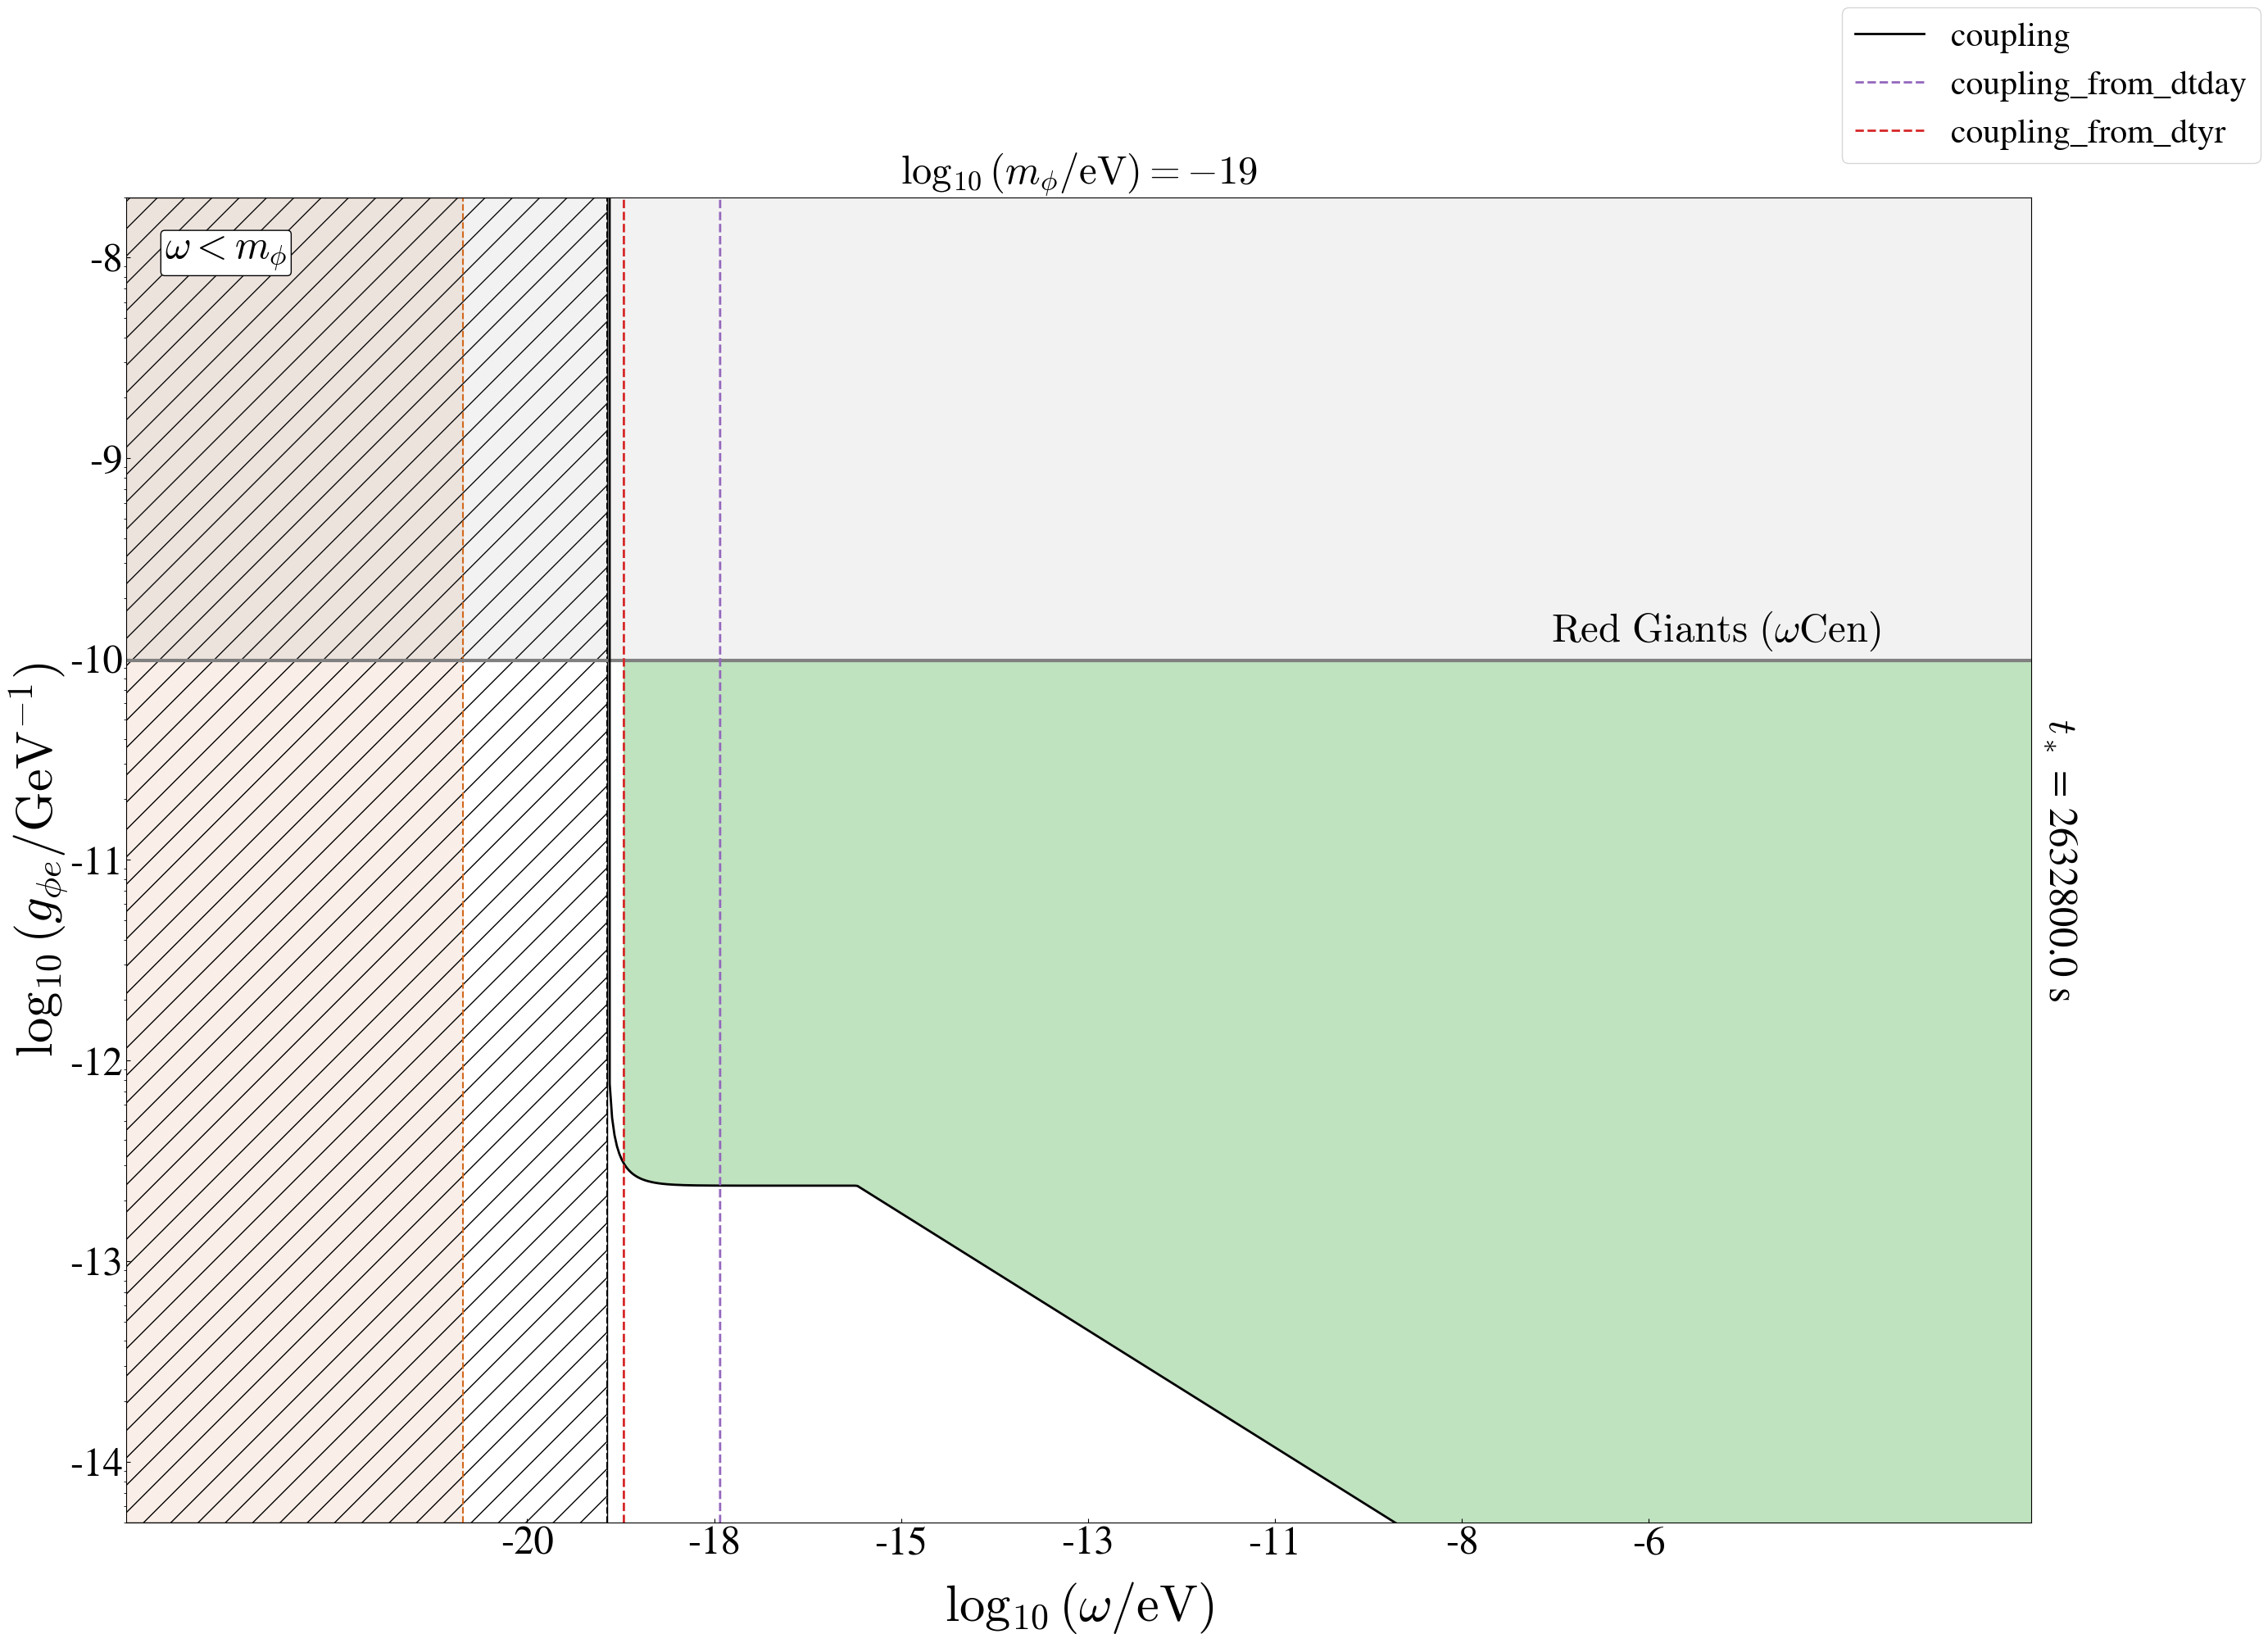

In [2]:
plot = Plot((1e-25, 6e-2), (5e-15, 2e-8), exclude_mass=False)
output = OutputHandler(plot)
output.plot_parameter_space(source, spectrum, plot, save_path='test1x1.png')